In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import scipy
import cartopy.crs as ccrs
import geopandas as gpd
import rioxarray
import cartopy.feature as cf
from rasterio.enums import Resampling


In [2]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }

In [3]:
meta_dict = {}
obs_dict = {}

In [4]:
# streamflow / catchment

# obs
obs_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/streamflow/streamflow_obs_autumn_converted.csv')
obs_df.date = pd.to_datetime(obs_df.date)
obs_df.set_index('date', inplace=True)
obs_df = obs_df['1969':'2019'] 

# meta
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)
subset_meta = metadata_df.loc[[int(s) for s in obs_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()
meta_df = gpd.GeoDataFrame(subset_meta,geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),crs='EPSG:4326')

# catchment
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
#catchment_data = catchment_data.to_crs("EPSG:32662")

catchment_data = catchment_data.loc[catchment_data['SITE'].isin(obs_df.columns)]
catchment_data.index = catchment_data['SITE']

meta_dict['streamflow'] = meta_df
obs_dict['streamflow'] = obs_df


In [5]:
# temperature 

# obs
df = pd.read_csv('/home/queenle/hydro_attribution/station_data/temperature_17_series/Combined17SS_02.csv')
df['date'] = df['STATS_YEAR'].astype(str) + '-' + df['STATS_MONTH'].astype(str)
df.index = pd.to_datetime(df['date'])

df_list = []
for site in df['station'].unique():
    ts = df.loc[df['station']==site]['newval']
    ts = ts.rename(site)
    df_list.append(ts)
    
obs_df = pd.concat(df_list, axis=1)

# meta
meta_df = pd.read_csv('/home/queenle/hydro_attribution/station_data/temperature_17_series/17SS_meta.csv')
meta_df.loc[6,'LONGT']=176.9 #slightly shift Napier so its nearest neighbor is not an ocean cell

meta_dict['temperature'] = meta_df
obs_dict['temperature'] = obs_df



In [6]:
# precip 

# obs
stations = ['Blenheim','Christchurch','Dunedin','Gisborne','Hamilton','Hokitika','Invercargill','Milford','Monowai','Napier',
           'Nelson','New Plymouth','Ngakuru','Palmerston North','Paraparaumu','Queenstown','Tauranga','Timaru','Wanganui',
           'Wellington','Whangarei']

df_list = []
for station in stations:
    df = pd.read_csv('/home/queenle/hydro_attribution/station_data/rainfall_21_series/'+station+'.csv')
    df['date'] = df['STATS_YEAR'].astype(str) + '-' + df['STATS_MONTH'].astype(str)
    df.index = pd.to_datetime(df['date'])
    ts = df['obs_value']
    ts = ts.rename(station)
    df_list.append(ts)

obs_df = pd.concat(df_list, axis=1)

# meta
meta_df = pd.read_csv('/home/queenle/hydro_attribution/station_data/rainfall_21_series/rainfall_stns.csv')
meta_df.loc[4,'LONGT']=176.9 #slightly shift Napier so its nearest neighbor is not an ocean cell
meta_df.loc[5,'LONGT']=175.25 #slightly shift Napier so its nearest neighbor is not an ocean cell

meta_dict['precipitation'] = meta_df
obs_dict['precipitation'] = obs_df


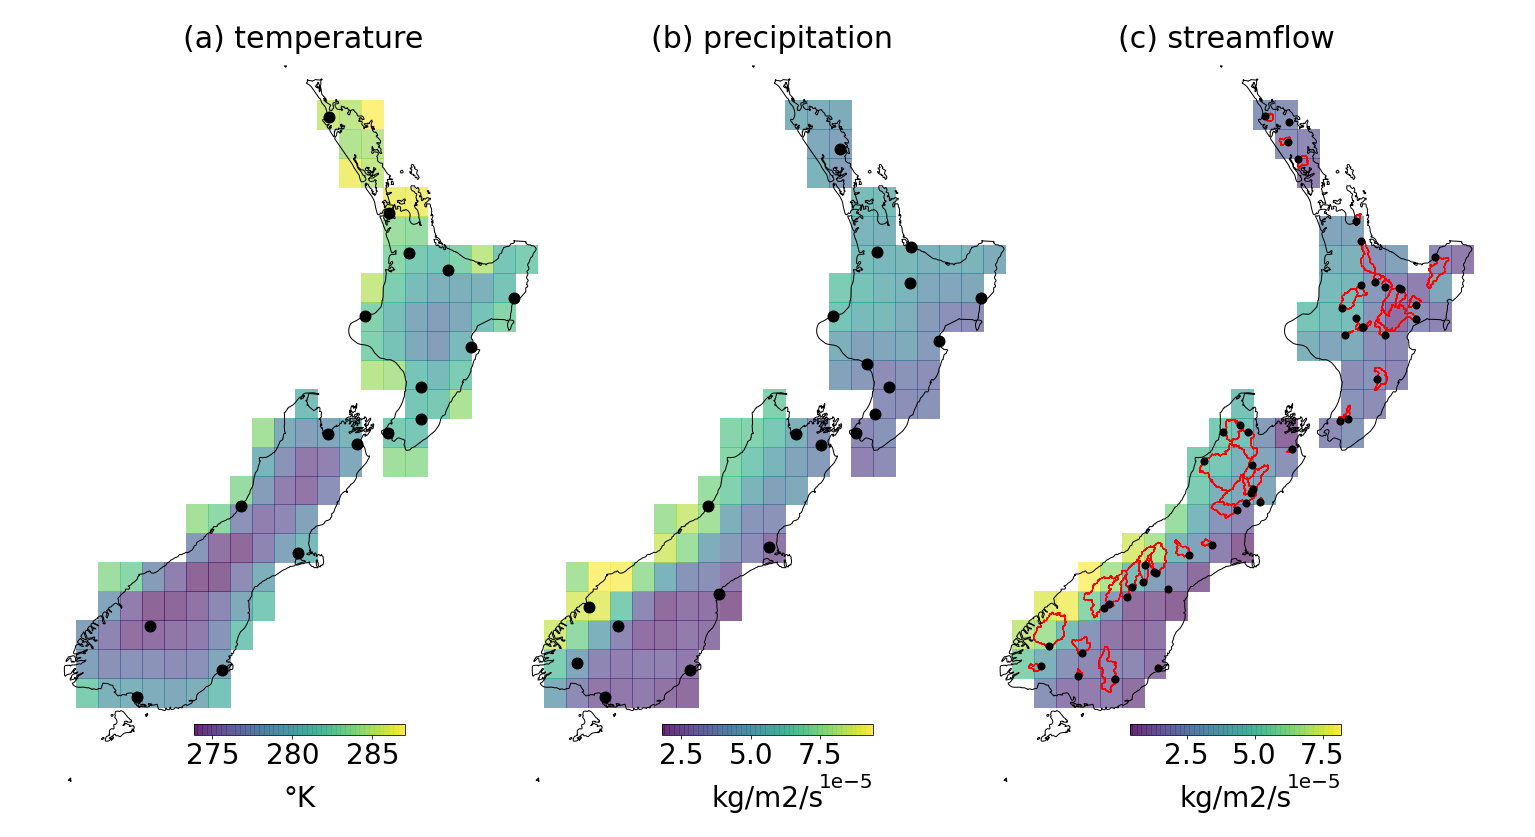

In [54]:
direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/'


fig,axs = plt.subplots(1,3,figsize=(22,15),subplot_kw=dict(projection=ccrs.PlateCarree()))
model_var = {'temperature':'TA','precipitation':'PRECIPI','streamflow':'ROF'}
units = {'temperature':'°K','precipitation':'kg/m2/s','streamflow':'kg/m2/s'}

labels = ['(a)','(b)','(c)']
for i,var in enumerate(['temperature','precipitation','streamflow']):
    
    #catchment_data['geometry'].plot(ax=ax,facecolor="none", edgecolor='red',linewidth=1)
        
    ax = axs[i]
    ax.patch.set_alpha(0)
    ax.axis('off')

    ex = xr.open_dataarray(f'{direc}{model_var[var]}/full/means/{model_var[var]}_Amon_d4PDF_HPB_FullEnsMean_raw_winter_1951-2021.nc')
    im = ex.mean('time').plot(ax=ax,add_colorbar=False,alpha=0.6)
    
    # Add a horizontal colorbar manually
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=-0.1, fraction=0.01)
    cbar.ax.tick_params(labelsize=28)
    cbar.ax.xaxis.get_offset_text().set_fontsize(20)
    cbar.set_label(units[var], fontsize=28,labelpad=15)
    
    obs = obs_dict[var]
    meta = meta_dict[var]
    
    lats = []
    lons = []
    for site in obs.columns:
        if var == 'streamflow':
            lat,lon = meta.loc[int(site)][['gauge_lat','gauge_lon']]
        else:
            lat,lon = meta.loc[meta['station']==site][['LAT','LONGT']].values[0]
        lats.append(lat)
        lons.append(lon)
    
    
    
    if var == 'streamflow':
        ax.scatter(lons,lats,c='black',zorder=2,s=50)
        catchment_data['geometry'].plot(ax=ax,facecolor="none", edgecolor='red',linewidth=1)
        
    else:
        ax.scatter(lons,lats,c='black',zorder=2,s=120)
        catchment_data['geometry'].plot(ax=ax,facecolor="none", edgecolor='red',linewidth=1,zorder=0,alpha=0)

    ax.coastlines()
    ax.add_feature(cf.BORDERS)
    ax.set_extent([165,180, -49,-33])#, crs=noproj)
    
    ax.set_title('')
    ax.text(0.3,0.95,f'{labels[i]} {var}',transform=ax.transAxes,fontdict=font)
    
               
plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.00,wspace=-.2, hspace=None)
    
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/station_network_figure.png',dpi=300, bbox_inches='tight', pad_inches=0.1)

NameError: name 'python' is not defined